## Исследовательский анализ данных о ДТП

Цель: посчитать и проанализировать статистические показатели ДТП за период 2015-2025 гг. Посмотреть и оценить влияние погодных условий на количество ДТП. Выявить иные факторы и аномалии при наличии.  Для анализа выбоаны два города г. Екатеринбург и г. Владивосток.

План работ:
- выгрузка данных из БД
- анализ основной стастистики по ДТП, в т.ч. в динамике, построение графиков
- выявление взаимосвязи количества ДТП с погодными условиями
- проверка гипотезы и влиянии количества осадков на количество ДТП
- расчет корреляции признаков (оценка влияния пострадал человек или нет в зависимости от других признаков)

In [1]:
# импорт библиотек
import time
from datetime import datetime, timedelta
from typing import List, Dict, Optional

import pandas as pd
import numpy as np

import sqlalchemy
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats


In [2]:
# Подключение к БД Supabase
load_dotenv()

# Параметры подключения
user = os.getenv('user')
password = os.getenv('password')
host = os.getenv('host')
port = '6543'
dbname = os.getenv('dbname')

# Адрес подключения
DATABASE_URL = f"postgresql+psycopg2://{user}:{password}@{host}:{port}/{dbname}?sslmode=require"

# Формируем движок
engine = create_engine(DATABASE_URL) 

try:
    with engine.connect() as connection:
        print(f'Подключение к базе успешно')
except Exception as e:
        print(f'Ошибка при подключении к базе: {e}')

Ошибка при подключении к базе: (psycopg2.OperationalError) server closed the connection unexpectedly
	This probably means the server terminated abnormally
	before or while processing the request.
server closed the connection unexpectedly
	This probably means the server terminated abnormally
	before or while processing the request.

[SQL: select pg_catalog.version()]
(Background on this error at: https://sqlalche.me/e/20/e3q8)


### 1. Основная статистика по ДТП

In [3]:
query1 = '''
    SELECT *
    FROM main_clean
    '''
main_clean = pd.read_sql_query(query1, con=engine)

main_clean.head()

,index,KartId,дата,время,район,вид_ДТП,погибло,ранено,количество ТС,количество участников,год,месяц,день,город
0,0,157114292,2015-01-02,12:30,Верх-Исетский,Наезд на стоящее ТС,0,1,2,3,2015,1,2,Екатеринбург
1,1,157122648,2015-01-02,17:15,Кировский,Наезд на пешехода,0,2,1,3,2015,1,2,Екатеринбург
2,2,157156173,2015-01-01,22:00,Октябрьский,Наезд на препятствие,0,1,1,1,2015,1,1,Екатеринбург
3,3,157223255,2015-01-01,02:20,Первомайский,Столкновение,0,2,2,3,2015,1,1,Владивосток
4,4,157225233,2015-01-01,14:30,Первореченский,Наезд на пешехода,0,1,1,2,2015,1,1,Владивосток


**Поскольку данные приведены только о днях когда было официально зафиксировано хоть 1 ДТП, то проверим были ли дни без ДТП**

In [4]:
# количество календарных дней за период 2015-2025
print(main_clean['дата'].max())
print(main_clean['дата'].min())

start_date = datetime(2015, 1, 1)
end_date = datetime(2025, 12, 31)

# Разница в днях
delta = end_date - start_date
total_days = delta.days + 1 
print('всего дней:', total_days)

2025-12-31 00:00:00
2015-01-01 00:00:00
всего дней: 4018


In [5]:
dekb = main_clean.loc[main_clean['город']=='Екатеринбург']
print(f"количество дней с ДТП за период 2015-2025 в Екб: {dekb['дата'].nunique()}")
print(f"количество дней без ДТП: {total_days - dekb['дата'].nunique()}")

dvlad = main_clean.loc[main_clean['город']=='Владивосток']
print(f"количество дней с ДТП за период 2015-2025 в Владивосток: {dvlad['дата'].nunique()}")
print(f"количество дней без ДТП: {total_days - dvlad['дата'].nunique()}")

количество дней с ДТП за период 2015-2025 в Екб: 3584
количество дней без ДТП: 434
количество дней с ДТП за период 2015-2025 в Владивосток: 3523
количество дней без ДТП: 495


Вывод почти 90% дней - происходит хоть 1 ДТП 

In [6]:
main_clean['KartId'].duplicated().sum()

np.int64(0)

In [7]:
query2 = '''
    SELECT *
    FROM info_dtp_clean
    '''
info_dtp_clean = pd.read_sql_query(query2, con=engine)
info_dtp_clean.head()

,index,KartId,город,категория_улиц,категория_дорог,покрытие,освещенность,недостатки_дороги,схема_расположения,погодные условия,дата,время,год,месяц
0,0,161237026,Екатеринбург,Улицы и дороги местного значения в жилой застр...,Не указано,Сухое,Светлое время суток,Недостатки зимнего содержания,Перегон (нет объектов на месте ДТП),Ясно,2015-01-31,15:30,2015,1
1,1,161340310,Екатеринбург,Улицы и дороги местного значения в жилой застр...,Не указано,Сухое,Светлое время суток,Не установлены,"Перегон (нет объектов на месте ДТП), Автостоян...",Ясно,2015-01-31,14:00,2015,1
2,2,161238027,Екатеринбург,Магистральные улицы районного значения,Не указано,Обработанное противогололедными материалами,"В темное время суток, освещение включено","Отсутствие, плохая различимость горизонтальной...",Перегон (нет объектов на месте ДТП),Пасмурно,2015-01-31,03:35,2015,1
3,3,171517613,Екатеринбург,Магистральные улицы районного значения,Не указано,Гололедица,"В темное время суток, освещение включено",Нарушения в размещении наружной рекламы,"Регулируемый пешеходный переход, Регулируемый ...",Ясно,2015-01-31,09:45,2015,1
4,4,160935023,Екатеринбург,Магистральные улицы районного значения,Не указано,Сухое,"В темное время суток, освещение включено","Отсутствие, плохая различимость горизонтальной...","Перегон (нет объектов на месте ДТП), Регулируе...",Пасмурно,2015-01-30,02:25,2015,1


In [8]:
info_dtp_clean['KartId'].duplicated().sum()

np.int64(0)

In [9]:
def statistics_DTP(df: pd.DataFrame, city: str):
    ''' 
    Строит линейную диаграмму по количеству ДТП и погибших за 2015-2025 по выбранному  городу
    '''

    df_city = df.loc[df['город']== city]
    year_statistics = df_city.groupby('год').agg({
        'KartId': 'count',       
        'погибло': 'sum'       
    }).reset_index()

    # Создаём график
    plt.figure(figsize=(10, 5))
    ax1 = plt.gca()  # основная ось (левая)

    # Строим первую линию — количество ДТП
    line1 = ax1.plot(
        year_statistics['год'],
        year_statistics['KartId'],
        marker='o',
        linestyle='-',
        linewidth=1,
        markersize=4,
        color='darkblue',
        label='Количество ДТП'
    )

    # Настраиваем подписи значений для первой линии
    for x, y in zip(year_statistics['год'], year_statistics['KartId']):
        ax1.annotate(
            f'{y}',
            xy=(x, y),
            xytext=(0, 5),
            textcoords='offset points',
            ha='center',
            va='bottom',
            fontsize=8,
            color='darkblue'
        )

    # Создаём вторую ось Y (правую) для количества погибших
    ax2 = ax1.twinx()
    
    # Строим вторую линию — количество погибших
    line2 = ax2.plot(
        year_statistics['год'],
        year_statistics['погибло'],
        marker='s',
        linestyle='--',
        linewidth=1,
        markersize=4,
        color='red',
        label='Количество погибших'
    )

    # Настраиваем подписи значений для второй линии
    for x, y in zip(year_statistics['год'], year_statistics['погибло']):
        ax2.annotate(
            f'{y}',
            xy=(x, y),
            xytext=(0, -10),  # смещаем вниз, чтобы не перекрывалось с первой линией
            textcoords='offset points',
            ha='center',
            va='top',
            fontsize=8,
            color='red'
        )
    
    # Настройки осей
    ax1.set_xlabel('Год', fontsize=12)
    ax1.set_ylabel('Количество ДТП', fontsize=12, color='darkblue')
    ax2.set_ylabel('Количество погибших', fontsize=12, color='red')
    
    # Стилизуем оси
    ax1.tick_params(axis='y', labelcolor='darkblue')
    ax2.tick_params(axis='y', labelcolor='red')
    
    # Заголовок и сетка
    plt.title('Динамика ДТП и количества погибших по годам', fontsize=14, pad=20)
    ax1.grid(True, alpha=0.3)
    
    # Легенда (объединяем легенды с обеих осей)
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    plt.legend([city], loc='upper left')
    
    # Устанавливаем деления на оси X (все годы)
    ax1.set_xticks(year_statistics['год'])
    
    # Отображаем график
    plt.show()

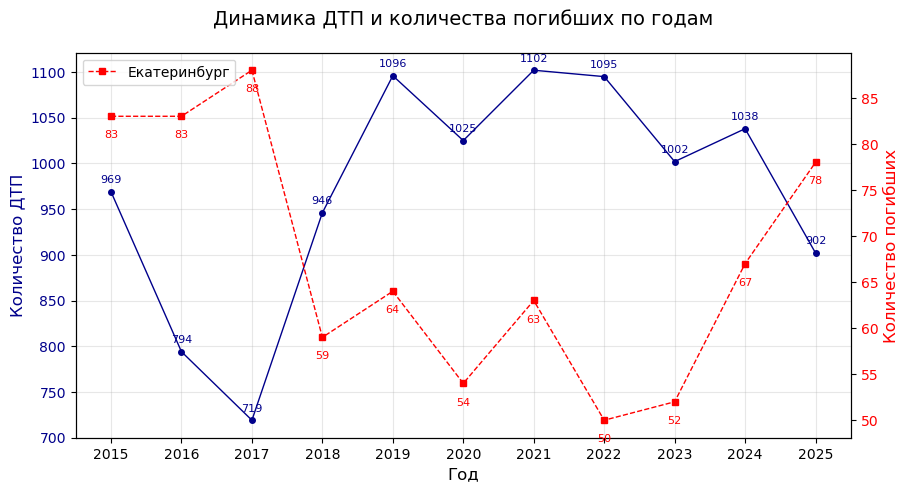

In [10]:
statistics_DTP(main_clean,'Екатеринбург')

Вывод: количество ДТП держится примерно на одном уровне с 2019, % погибших в пределах 5-10%

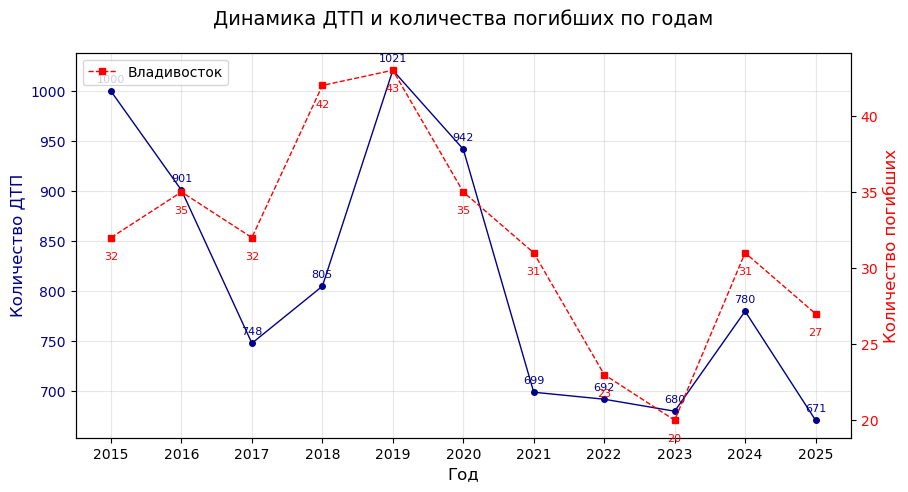

In [11]:
statistics_DTP(main_clean,'Владивосток')

Вывод: положительная динамика - снижение количества ДТП  и погибших почти на 30% с пика в 2019г

In [12]:
def value_counts_polt(df: pd.DataFrame, column: str, city: str):
    ''' 
    Строит барпплот ТОП-1О по количеству ДТП за 2015-2025 по выбранному признаку и городу
    '''
    df_plot = (df.loc[df['город']== city]
        .groupby([column]).agg({'KartId':'count'}).reset_index()
        .sort_values(by='KartId', ascending =False).head(10)
              )
    df_plot.plot(
    kind='bar',
    x=column,
    y='KartId',
    figsize=(8, 4),
    color='skyblue',
    edgecolor='navy',
    linewidth=1
)

    plt.title(f'ТОП-10 по {column} в 2015-2025', fontsize=10)
    plt.xlabel(column, fontsize=8)
    plt.ylabel('Количество ДТП', fontsize=8)
    plt.legend([city], loc='upper left', bbox_to_anchor=(1.02, 1))
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)

    plt.show()

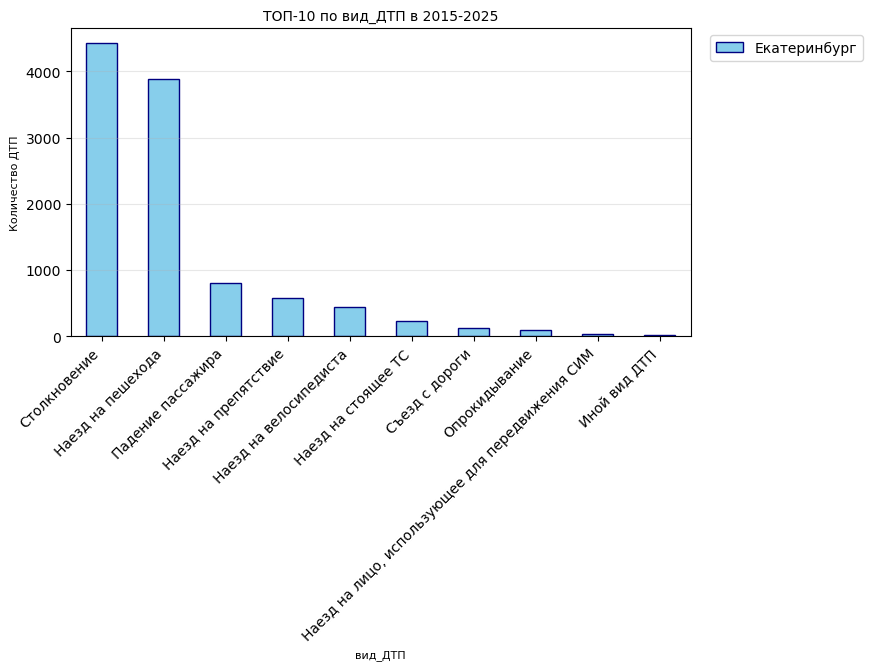

In [13]:
value_counts_polt(main_clean,'вид_ДТП','Екатеринбург')

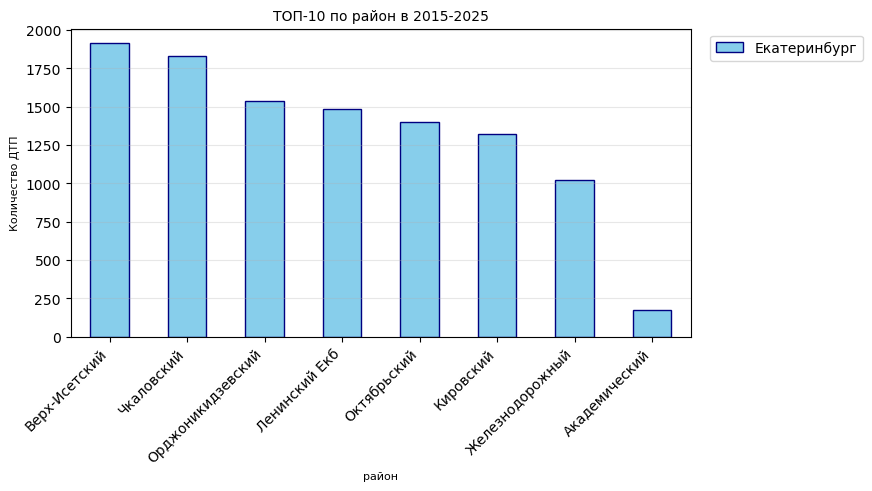

In [14]:
value_counts_polt(main_clean,'район','Екатеринбург')

### 2. Влияние погоды на ДТП

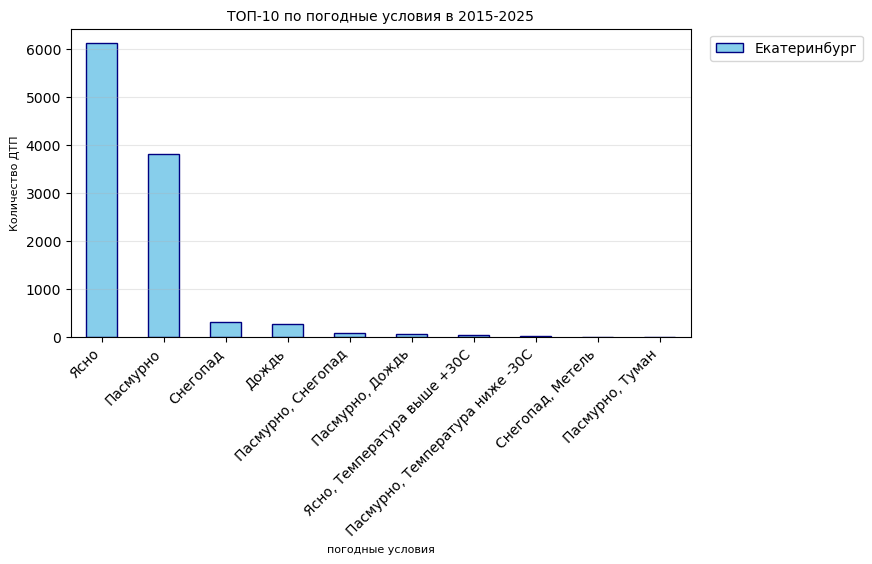

In [15]:
value_counts_polt(info_dtp_clean,'погодные условия','Екатеринбург')

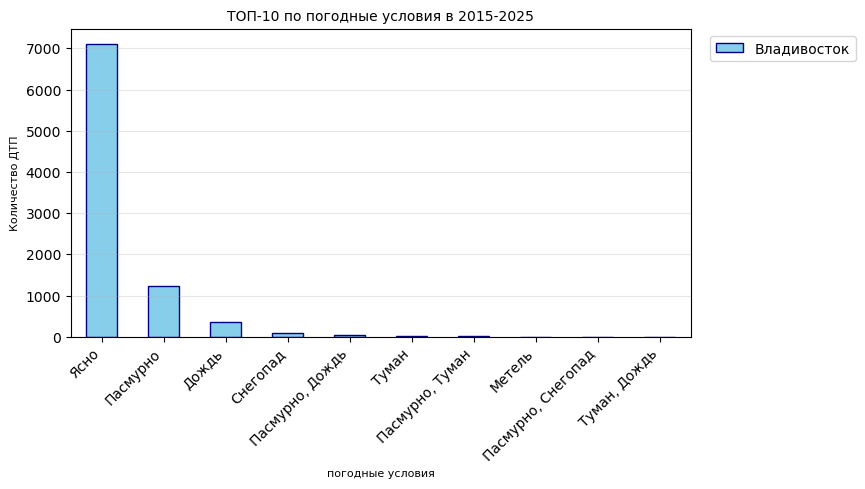

In [16]:
value_counts_polt(info_dtp_clean,'погодные условия','Владивосток')

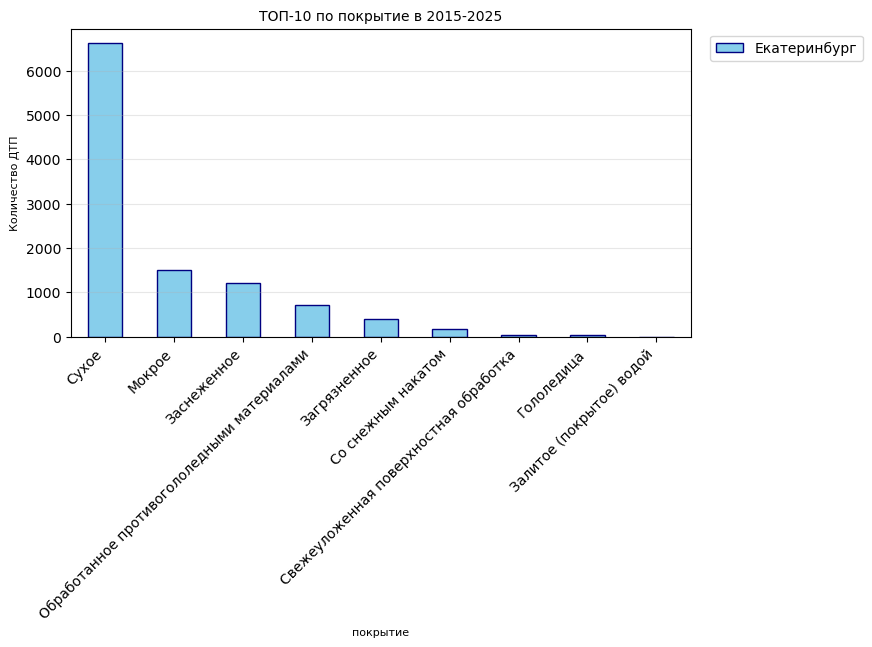

In [17]:
value_counts_polt(info_dtp_clean,'покрытие','Екатеринбург')

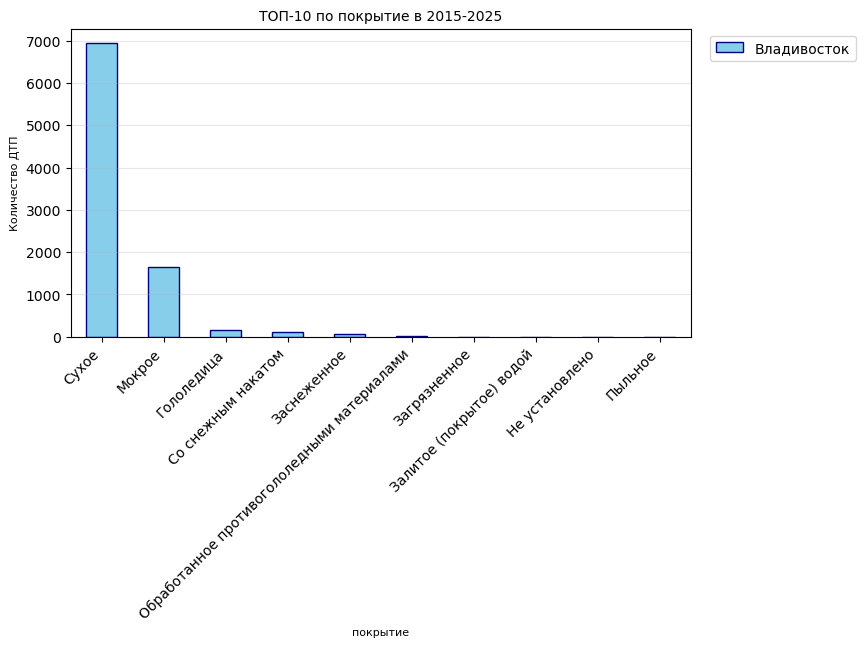

In [18]:
value_counts_polt(info_dtp_clean,'покрытие','Владивосток')

Вывод: большая часть ДТП совершена при сухой и ясной погоде в обоих городах.  Однако делать вывод о невлиянии погодных условий на количество ДТП в данном случае некорректно. В данных информация только о днях, когда было хоть одно ДТП. Кроме того в данных нет информации о количестве выезжающих на дороги машин в целом (т.е. в плохую погоду меньше трафик, следовательно и ДТП меньше, однако в % отношении об ощего числа машин на дорогах, эта статистика может быть другой).

### 2.1 Выделим дни с аномальным количеством ДТП

In [19]:
def extra_DTP_days (city: str):
    '''Сторит боксплот по количеству дтп по выбранному городу '''
    
    df_city = main_clean.loc[main_clean['город']== city]
    day_dtp = df_city.groupby(['дата']).agg({
                                     'KartId':'count',
                                     'погибло':'sum',
                                      'ранено':'sum'
                                     }).reset_index().sort_values(by='KartId', ascending = False)
    day_dtp.rename(columns={'KartId': 'количество_дтп'}, inplace=True)

    day_dtp.boxplot()
    plt.title('Распределение показателей ДТП', fontsize=12)
    plt.ylabel('Количество', fontsize=12)
    ymin, ymax = plt.ylim()
    plt.yticks(np.arange(int(ymin), int(ymax) + 1, 2))
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    
    plt.show()

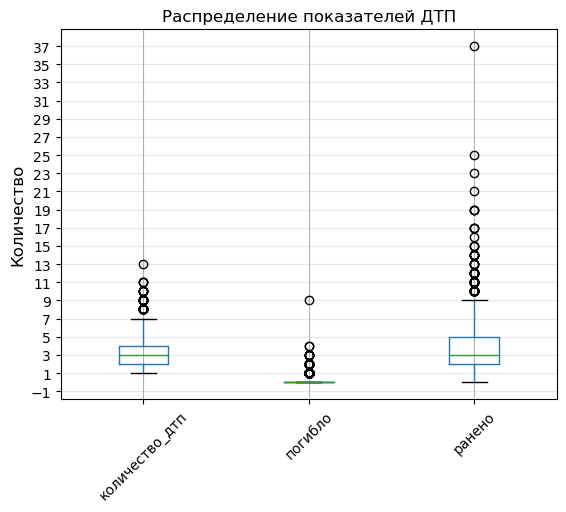

In [20]:
extra_DTP_days('Екатеринбург')

Вывод: количество ДТП в день больше 7 является аномальным для Екб. 

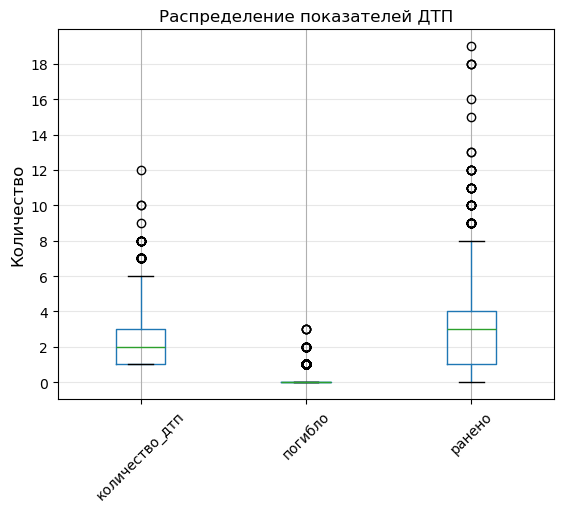

In [21]:
extra_DTP_days('Владивосток')

Вывод: показатели во Владивостоке схожи с показателями Екб: количество ДТП в день больше 6 является аномальным. 

### 2.2 Проанализируем погоду в дни с "аномальным" количеством ДТП для Екатеринбурга

In [22]:
df_city = info_dtp_clean.loc[info_dtp_clean['город']=='Екатеринбург'].groupby(['дата']).agg({'KartId':'count'}).reset_index()
df_city = df_city.loc[df_city['KartId']>=7]

# список дней с аномальным количеством ДТП
bad_days = pd.to_datetime(df_city['дата']).tolist()
len(bad_days)

144

Вывод за период 2015-2025 в Екб было 144 дня, когда количество дтп больше  или = 7

In [23]:
# сформируем отдельный датафрейм с аномальными днями
extra_dtp_ekb = info_dtp_clean.loc[(info_dtp_clean['город']=='Екатеринбург')&(info_dtp_clean['дата'].isin(bad_days))]

extra_dtp_ekb.head()

,index,KartId,город,категория_улиц,категория_дорог,покрытие,освещенность,недостатки_дороги,схема_расположения,погодные условия,дата,время,год,месяц
49,47,167392329,Екатеринбург,Магистральные улицы районного значения,Не указано,Заснеженное,"В темное время суток, освещение включено","Отсутствие, плохая различимость горизонтальной...",Перегон (нет объектов на месте ДТП),Пасмурно,2015-01-16,18:40,2015,1
50,48,159466409,Екатеринбург,Магистральные улицы районного значения,Не указано,Заснеженное,"В темное время суток, освещение включено",Недостатки зимнего содержания,"Перегон (нет объектов на месте ДТП), Регулируе...",Снегопад,2015-01-16,17:45,2015,1
51,49,159466398,Екатеринбург,Магистральные улицы общегородского значения,Не указано,Заснеженное,Светлое время суток,Недостатки зимнего содержания,"Перегон (нет объектов на месте ДТП), Автостоян...",Снегопад,2015-01-16,14:30,2015,1
52,50,159466436,Екатеринбург,Магистральные улицы районного значения,Не указано,Заснеженное,"В темное время суток, освещение включено",Не установлены,"Перегон (нет объектов на месте ДТП), Регулируе...",Пасмурно,2015-01-16,20:30,2015,1
53,51,159466472,Екатеринбург,Магистральные улицы районного значения,Не указано,Заснеженное,Светлое время суток,Недостатки зимнего содержания,Перегон (нет объектов на месте ДТП),Снегопад,2015-01-16,15:10,2015,1


### 2.3 Выгрузим данные о погоде для Екатеринбурга


In [24]:
query3 = '''
    SELECT *
    FROM "meteo_Ekaterinburg"
    '''
meteo_ekb = pd.read_sql_query(query3, con=engine)
meteo_ekb.info()
meteo_ekb.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4019 entries, 0 to 4018
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   index                4019 non-null   int64  
 1   latitude             4019 non-null   float64
 2   longitude            4019 non-null   float64
 3   time                 4019 non-null   object 
 4   temperature_2m_mean  4019 non-null   float64
 5   temperature_2m_min   4019 non-null   float64
 6   wind_speed_10m_max   4019 non-null   float64
 7   precipitation_sum    4019 non-null   float64
 8   rain_sum             4019 non-null   float64
 9   snowfall_sum         4019 non-null   float64
 10  precipitation_hours  4019 non-null   float64
 11  temperature_2m_max   4019 non-null   float64
 12  city                 4019 non-null   object 
dtypes: float64(10), int64(1), object(2)
memory usage: 408.3+ KB


,index,latitude,longitude,time,temperature_2m_mean,temperature_2m_min,wind_speed_10m_max,precipitation_sum,rain_sum,snowfall_sum,precipitation_hours,temperature_2m_max,city
0,0,56.906853,60.63158,2015-01-01,-23.4,-27.7,11.5,0.0,0.0,0.00,0.0,-20.0,Екатеринбург
1,0,56.906853,60.63158,2015-01-02,-27.5,-29.7,9.2,0.0,0.0,0.00,0.0,-24.2,Екатеринбург
2,0,56.906853,60.63158,2015-01-03,-21.3,-29.8,18.4,0.9,0.0,1.05,6.0,-10.0,Екатеринбург
3,0,56.906853,60.63158,2015-01-04,-4.5,-8.1,19.1,1.0,0.0,0.77,5.0,-3.0,Екатеринбург
4,0,56.906853,60.63158,2015-01-05,-4.0,-6.4,18.7,0.0,0.0,0.00,0.0,-2.0,Екатеринбург


In [25]:
# предобработка и чистка данных
# meteo_ekb = meteo_ekb.drop(columns=['index', 'latitude','longitude'])
meteo_ekb = meteo_ekb.rename(columns={'time': 'date'})
meteo_ekb['date'] = pd.to_datetime(meteo_ekb['date'], format='%Y-%m-%d')
meteo_ekb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4019 entries, 0 to 4018
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   index                4019 non-null   int64         
 1   latitude             4019 non-null   float64       
 2   longitude            4019 non-null   float64       
 3   date                 4019 non-null   datetime64[ns]
 4   temperature_2m_mean  4019 non-null   float64       
 5   temperature_2m_min   4019 non-null   float64       
 6   wind_speed_10m_max   4019 non-null   float64       
 7   precipitation_sum    4019 non-null   float64       
 8   rain_sum             4019 non-null   float64       
 9   snowfall_sum         4019 non-null   float64       
 10  precipitation_hours  4019 non-null   float64       
 11  temperature_2m_max   4019 non-null   float64       
 12  city                 4019 non-null   object        
dtypes: datetime64[ns](1), float64(10)

In [26]:
# оставим погодные дни с аномальным количеством дтп
extra_meteo_ekb = meteo_ekb.loc[meteo_ekb['date'].isin(bad_days)]
print(len(extra_meteo_ekb))

# выделим день и месяц из даты
extra_meteo_ekb['year'] = extra_meteo_ekb['date'].dt.year
extra_meteo_ekb['month'] = extra_meteo_ekb['date'].dt.month
extra_meteo_ekb['day'] = extra_meteo_ekb['date'].dt.day


144


C:\Users\Sandy\AppData\Local\Temp\ipykernel_6260\2853183845.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  extra_meteo_ekb['year'] = extra_meteo_ekb['date'].dt.year
C:\Users\Sandy\AppData\Local\Temp\ipykernel_6260\2853183845.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  extra_meteo_ekb['month'] = extra_meteo_ekb['date'].dt.month
C:\Users\Sandy\AppData\Local\Temp\ipykernel_6260\2853183845.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .l

**Посчитаем средние значения показателей погоды для каждого дня каждого месяца**

In [27]:
# добавляем отдельные столбы с годом, месяцем, днем
meteo_mean = meteo_ekb.copy()
meteo_mean['year'] = meteo_mean['date'].dt.year
meteo_mean['month'] = meteo_mean['date'].dt.month
meteo_mean['day'] = meteo_mean['date'].dt.day


In [28]:
meteo_mean = meteo_mean.groupby(['month','day']).agg({'temperature_2m_mean':'mean',
                                    'temperature_2m_min':'mean',
                                    'temperature_2m_max':'mean',
                                    'wind_speed_10m_max':'mean',
                                    'rain_sum':'mean',
                                    'snowfall_sum':'mean',
                                    'precipitation_sum':'mean',
                                    'precipitation_hours':'mean',
                                                     
                                    }).reset_index()
meteo_mean = meteo_mean.round(1)
meteo_mean

,month,day,temperature_2m_mean,temperature_2m_min,temperature_2m_max,wind_speed_10m_max,rain_sum,snowfall_sum,precipitation_sum,precipitation_hours
0,1,1,-13.8,-16.8,-11.6,17.2,0.0,0.9,1.3,4.6
1,1,2,-14.6,-17.4,-12.1,16.7,0.0,0.8,1.2,5.7
2,1,3,-12.4,-16.2,-9.4,18.5,0.0,0.6,0.9,4.5
3,1,4,-11.4,-14.6,-8.1,17.6,0.0,0.9,1.2,6.6
4,1,5,-13.8,-16.2,-11.4,15.2,0.1,0.3,0.4,3.4
...,...,...,...,...,...,...,...,...,...,...
361,12,27,-11.8,-14.9,-9.0,18.1,0.0,0.9,1.2,5.9
362,12,28,-10.5,-14.0,-7.9,15.7,0.0,0.7,0.9,4.8
363,12,29,-11.6,-14.4,-9.0,16.9,0.0,0.4,0.5,2.7
364,12,30,-14.4,-16.5,-12.5,15.6,0.0,0.1,0.1,0.8


**Сравним погодные условия в день ДТП со средними показателями для этого дня и месяца**

In [29]:
merged_df = pd.merge(
    extra_meteo_ekb,
    meteo_mean,
    on=['month', 'day'],
    how='left',
    suffixes=('_actual', '_average')
)
merged_df.head()

,index,latitude,longitude,date,temperature_2m_mean_actual,temperature_2m_min_actual,wind_speed_10m_max_actual,precipitation_sum_actual,rain_sum_actual,snowfall_sum_actual,...,month,day,temperature_2m_mean_average,temperature_2m_min_average,temperature_2m_max_average,wind_speed_10m_max_average,rain_sum_average,snowfall_sum_average,precipitation_sum_average,precipitation_hours_average
0,0,56.906853,60.63158,2015-01-16,-1.2,-2.7,16.6,3.5,0.0,2.8,...,1,16,-8.4,-11.1,-6.1,18.7,0.0,0.7,1.0,4.5
1,0,56.906853,60.63158,2015-02-14,-6.5,-8.0,22.1,0.0,0.0,0.0,...,2,14,-9.4,-12.2,-6.5,16.5,0.0,0.1,0.1,1.1
2,0,56.906853,60.63158,2015-06-18,23.6,16.2,15.7,0.0,0.0,0.0,...,6,18,16.5,11.9,20.9,17.3,2.4,0.0,2.4,3.1
3,0,56.906853,60.63158,2015-07-17,15.7,13.7,8.5,15.5,15.5,0.0,...,7,17,19.7,15.0,24.1,15.6,2.3,0.0,2.3,4.1
4,0,56.906853,60.63158,2015-07-20,14.8,9.0,12.6,0.0,0.0,0.0,...,7,20,19.6,14.8,24.0,15.7,3.8,0.0,3.8,3.9


In [30]:
#посчитаем отклонение для некоторых показателей от средних значений
temperature_columns = ['temperature_2m_min', 'temperature_2m_max', 'precipitation_sum']
                                                   
for col in temperature_columns:
    actual_col = f'{col}_actual'
    average_col = f'{col}_average'
    
    # если среднее значение = 0, отклонение считаем по абсолютной разнице
    condition = merged_df[average_col] != 0
    merged_df[f'{col}_deviation_pct'] = np.where(
        condition,
        ((merged_df[actual_col] - merged_df[average_col]) / merged_df[average_col]) * 100,
        np.where(
            merged_df[actual_col] == 0,  # если оба 0 — отклонение 0 %
            0,
            100  # если среднее 0, а фактическое ≠ 0 — отклонение 100 %
        )
    )

# Определяем, есть ли отклонение > 100 % 
deviation_cols = [f'{col}_deviation_pct' for col in temperature_columns]
merged_df['has_large_deviation'] = (
    merged_df[deviation_cols].abs() > 100
).any(axis=1)

# Фильтруем строки с отклонениями 
outliers_df = merged_df[merged_df['has_large_deviation']].copy()

# Оставляем только нужные столбцы в итоговом датафрейме
result_columns = ['date']
for col in temperature_columns:
    result_columns.extend([f'{col}_actual', f'{col}_average', f'{col}_deviation_pct'])

outliers_df = outliers_df[result_columns]

# Сортируем по дате 
outliers_df = outliers_df.sort_values('date').reset_index(drop=True)

In [31]:
len(outliers_df)

52

Вывод: большое количество дней 52 из 144, когда погодные условия в день ДТП более чем на 100% раза отличались от средних показателей. Однако здесь учитывается отличие в обе стороны (в лучшую и худшую).  

In [32]:
# выделим дни экстремальными погодой 
extra_meteo_ekb.loc[
    (extra_meteo_ekb['temperature_2m_max']>30)|
    (extra_meteo_ekb['temperature_2m_min']<-25)|
    
    (extra_meteo_ekb['precipitation_sum']>10)
    ]

,index,latitude,longitude,date,temperature_2m_mean,temperature_2m_min,wind_speed_10m_max,precipitation_sum,rain_sum,snowfall_sum,precipitation_hours,temperature_2m_max,city,year,month,day
197,0,56.906853,60.63158,2015-07-17,15.7,13.7,8.5,15.5,15.5,0.0,17.0,19.4,Екатеринбург,2015,7,17
221,0,56.906853,60.63158,2015-08-10,14.5,11.9,15.5,10.1,10.1,0.0,14.0,17.3,Екатеринбург,2015,8,10
716,0,56.906853,60.63158,2016-12-17,-22.8,-26.0,15.2,0.0,0.0,0.0,0.0,-20.6,Екатеринбург,2016,12,17
1722,0,56.906853,60.63158,2019-09-19,7.7,5.7,24.3,12.2,12.2,0.0,14.0,9.3,Екатеринбург,2019,9,19
2327,0,56.906853,60.63158,2021-05-16,24.9,18.1,22.0,0.0,0.0,0.0,0.0,31.6,Екатеринбург,2021,5,16
3451,0,56.906853,60.63158,2024-06-13,24.9,18.4,13.9,0.0,0.0,0.0,0.0,30.5,Екатеринбург,2024,6,13


Вывод: дней из экстремальными показателями погоды было всего 6 из 144. 

### 3. Проверка гипотезы

Проверим гипотезу о влиянии количества осадков на количество ДТП в Екатеринбурге.

Н0: количества осадков в день не влияет на количество ДТП в день.

H1: количества осадков влияет на количество ДТП 

уровень статистической значимости = 0,05

In [33]:
# подготовим инфо по Екб
info_ekb = info_dtp_clean.loc[info_dtp_clean['город']=='Екатеринбург'].groupby(['дата']).agg({'KartId':'count'}).reset_index()
# info_ekb = info_ekb.groupby(['дата']).agg({'KartId':'count'})
info_ekb = info_ekb.rename(columns={'дата':'date',
                                    'KartId':'количество ДТП'
                                   })
                                   


In [34]:
# посмотрим распределение осадков и ДТП
def get_hist(df: pd.DataFrame, column: str):
    '''
    Строит гистограммы для выбранного признака
    '''
    df[column].hist(
        bins=10,
        figsize=(8, 4),
        color='skyblue',
        edgecolor='black',
        
    )
   
    plt.suptitle(f'Гистограмма {column}', fontsize=10)
    plt.xlabel(column, fontsize=8)
    plt.ylabel('Количество дней', fontsize=10)
    plt.show()

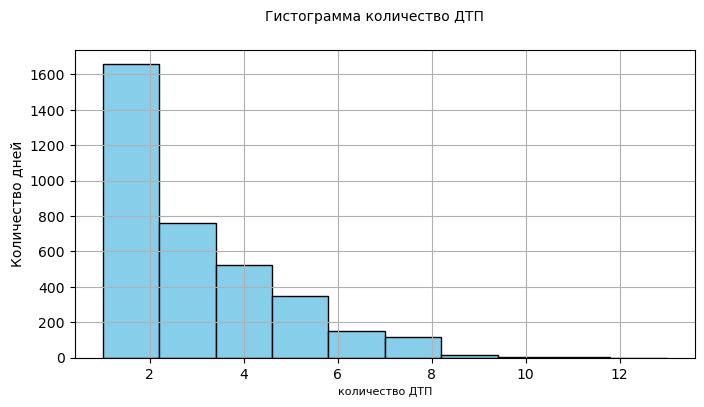

In [35]:
get_hist(info_ekb, 'количество ДТП')

Вывод: не больше 2-x ДТП в день чаще всего

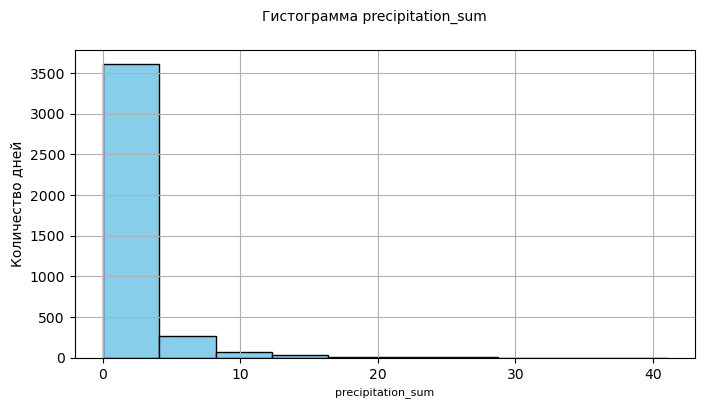

In [36]:
get_hist(meteo_ekb, 'precipitation_sum')

Вывод: не больше 5 мм осадков в день чаще всего

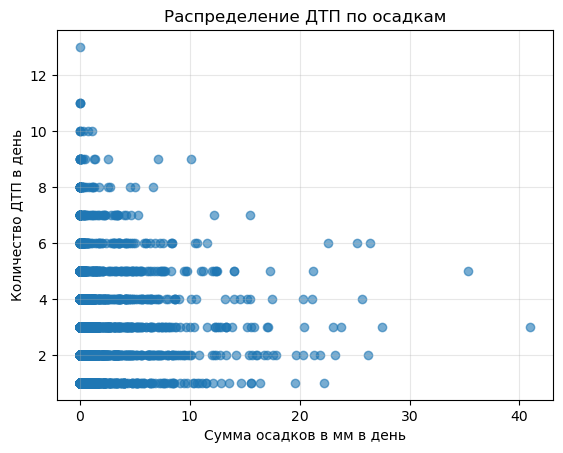

In [37]:
# подготовим данные 
info_ekb_count = pd.merge(info_ekb, meteo_ekb[['date','temperature_2m_min', 'precipitation_sum', 'temperature_2m_max']], 
                         on='date', how='left')

# построим даиграмму рассеяния
plt.scatter(info_ekb_count['precipitation_sum'], info_ekb_count['количество ДТП'], alpha=0.6)
plt.title('Распределение ДТП по осадкам')
plt.ylabel('Количество ДТП в день')
plt.xlabel('Сумма осадков в мм в день')
plt.grid(True, alpha=0.3)
plt.show()

Вывод: диаграмма подтверждает, что большая часть дтп происходит в сухую погоду, т.к. именно сухая погода более типична для региона.

In [38]:
pearson_corr = stats.pearsonr(info_ekb_count['precipitation_sum'], info_ekb_count['количество ДТП'])
spearman_corr = stats.spearmanr(info_ekb_count['precipitation_sum'], info_ekb_count['количество ДТП'])
print(f"\nКорреляция Пирсона: {pearson_corr[0]:.2f}")
print(f"Корреляция Спирмана: {spearman_corr[0]:.2f}")


Корреляция Пирсона: 0.03
Корреляция Спирмана: 0.04


Вывод: низкое значение корреляции показывает отсутствие взаимосвязи

In [39]:
# категорируем данные по осадкам и количеству ДТП
info_ekb_count['precipitation_group'] = pd.cut(info_ekb_count['precipitation_sum'],
                               bins=[-1, 0, 10, np.inf],
                               labels=['no_precipitation', 'small_precipitation', 'strong_precipitation'])

ekb_stats = info_ekb_count.groupby('precipitation_group')['количество ДТП'].agg(['count']).round(2)
ekb_stats

C:\Users\Sandy\AppData\Local\Temp\ipykernel_6260\1870808368.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ekb_stats = info_ekb_count.groupby('precipitation_group')['количество ДТП'].agg(['count']).round(2)


,count
precipitation_group,
no_precipitation,1724
small_precipitation,1769
strong_precipitation,91


In [40]:
# Тест ANOVA для сравнения средних между группами
f_stat, anova_p = stats.f_oneway(
    info_ekb_count[info_ekb_count['precipitation_group'] == 'no_precipitation']['количество ДТП'],
    info_ekb_count[info_ekb_count['precipitation_group'] == 'small_precipitation']['количество ДТП'],
    info_ekb_count[info_ekb_count['precipitation_group'] == 'strong_precipitation']['количество ДТП']
)
print(f"\nТест ANOVA: F‑статистика = {f_stat:.3f}, p‑значение = {anova_p:.3f}")


Тест ANOVA: F‑статистика = 1.223, p‑значение = 0.294


**Вывод:** поскольку  p-значение >0,05, не отвергаем нулевую гипотезу (H₀). Нет статистически значимых различий в количестве ДТП между днями с разными уровнями осадков (без осадков, слабые осадки, сильные осадки) на этом наборе даннных. 
**При этом следует учитывать, что в плохую погоду меньше трафик, следовательно и ДТП меньше, однако в % отношении об ощего числа машин на дорогах, эта статистика может быть другой.** 

### 4. Категоризация данных. Расчет корреляции

Проверим корреляцию между тем пострадал ли человек и наличием алкоголя, а также пристегнутого ремня безопасности

In [41]:
query4 = '''
    SELECT *
    FROM uch_clean
    '''
uch_clean = pd.read_sql_query(query4, con=engine)

uch_clean.head()

,index,KartId,категория_пострадавшего,степень_тяжести_пострадавшего,пол,стаж_вождения,наличие_алкоголя,пристегнут_ремень_безопасности,нарушение_пдд,дополнительные_нарушения,город
0,0,157114292,Водитель,Не пострадал,Мужской,16,нет данных,Да,Несоответствие скорости конкретным условиям дв...,Несоблюдение требований ОСАГО,Екатеринбург
1,1,157114292,Водитель,Не пострадал,Мужской,5,нет данных,Да,Нет нарушений,Нет нарушений,Екатеринбург
2,2,157114292,Пассажир,"Раненый, находящийся (находившийся) на стацион...",Женский,нет данных,нет данных,Да,Нет нарушений,Нет нарушений,Екатеринбург
3,3,157122648,Водитель,Не пострадал,Мужской,10,нет данных,Да,Нет нарушений,Несоблюдение требований ОСАГО,Екатеринбург
4,4,157156173,Водитель,"Раненый, находящийся (находившийся) на стацион...",Мужской,4,нет данных,Да,Несоответствие скорости конкретным условиям дв...,Нет нарушений,Екатеринбург


In [42]:
uch_clean['пристегнут_ремень_безопасности'].unique()

array(['Да', 'Нет', 'нет данных'], dtype=object)

In [43]:
#  категоризация данных
def set_belt_category(value):
    if value == 'Да':
        return 0
    elif pd.isna(value) or value == 'нет данных':
        return None  
    else:
        return 1

In [44]:
uch_clean['категория_ремень_безопасности'] = uch_clean['пристегнут_ремень_безопасности'].apply(set_belt_category)

In [45]:
uch_clean['степень_тяжести_пострадавшего'].unique()

array(['Не пострадал',
       'Раненый, находящийся (находившийся) на стационарном лечении',
       'нет данных',
       'Раненый, находящийся (находившийся)  на амбулаторном лечении, либо которому по характеру полученных травм обозначена необходимость амбулаторного лечения (вне зависимости от его фактического прохождения)',
       'Скончался в течение 2 суток',
       'Скончался на месте ДТП до приезда скорой медицинской помощи',
       'Скончался в течение 1 суток', 'Скончался в течение 8 суток',
       'Скончался в течение 10 суток',
       'Получил травмы с оказанием разовой медицинской помощи, к категории раненый не относится',
       'Скончался на месте ДТП по прибытию скорой медицинской помощи, но до транспортировки в медицинское учреждение',
       'Скончался в течение 4 суток', 'Скончался в течение 7 суток',
       'Скончался в течение 3 суток', 'Скончался в течение 9 суток',
       'Скончался в течение 14 суток', 'Скончался в течение 16 суток',
       'Скончался при транспорт

In [46]:
def set_injury_category(value):
    if value == 'Не пострадал':
        return 0
    elif pd.isna(value) or value == 'нет данных':
        return None  
    else:
        return 1
        

In [47]:
uch_clean['категория_пострадавшего'] = uch_clean['степень_тяжести_пострадавшего'].apply(set_injury_category)

In [48]:
uch_clean['наличие_алкоголя'].unique()


array(['нет данных', '20', '00', '15', '09', '02', '17', '08', '30', '03',
       '88', '05', '27', '19', '04', '12', '11', '01', '39', '07', '10',
       '25', '14', '06', '22', '99', '32', '40', '60', '16', '13', '21',
       '18', '23', '50', '33', '29', '28', '31', '26', '24', '35', '37',
       '51', '55', '34', '38', '41', '42'], dtype=object)

In [49]:
def set_alcohol_category(value):
    if (value == '03' or # допустимая норма для водителей в РФ
        value =='02' or
        value =='01' or
        value == '00'):
        return 0
    elif pd.isna(value) or value == 'нет данных':
        return None  
    else:
        return 1

In [50]:
uch_clean['категория_алкоголя'] = uch_clean['наличие_алкоголя'].apply(set_alcohol_category)

In [51]:
uch1 = uch_clean.loc[:,['категория_пострадавшего','категория_ремень_безопасности', 'категория_алкоголя']]
uch1 =uch1.dropna()

In [52]:
# построим матрицу корреляции Пирсона
corr_matrix_Prs = uch1.corr()
corr_matrix_Prs

,категория_пострадавшего,категория_ремень_безопасности,категория_алкоголя
категория_пострадавшего,1.000000,0.246088,0.099617
категория_ремень_безопасности,0.246088,1.000000,0.165331
категория_алкоголя,0.099617,0.165331,1.000000


Вывод: данные  показывают  слабую корреляцию  между категорией пострадавшего и наличием алкоголя, взаимосвязь с наличием ремня безопасности сильнее, однако тоже незначительная (менее 0,5). 

### Итоговый вывод по анализу данных

- Проанализированы основные статистические показатели ДТП за период 2015-2025 гг. по г. Екатеринбург и Владивосток. Следует отметить общую положительную тенденцию снижения количества ДТП. 
- Оценено влияние погодных условий на количество ДТП в г. Екатеринбурге. 
- Проверена гипотеза о влиянии количества осадков на количество ДТП в г.Екатеринбурге. По итогампроверки можно сделать вывод, что нет статистически значимых различий в количестве ДТП между днями с разными уровнями осадков (без осадков, слабые осадки, сильные осадки) на этом наборе даннных. 
При этом следует учитывать, что в плохую погоду меньше трафик, следовательно и ДТП меньше, однако в % отношении об ощего числа машин на дорогах, эта статистика может быть другой. 
- Проведена оценка влияния пострадал человек или нет в зависимости от наличия пристегнутого ремня безопасности и уровня алкоголя. Данные  показали  слабую корреляцию  между категорией пострадавшего и наличием алкоголя, взаимосвязь с наличием ремня безопасности сильнее, однако тоже незначительная (менее 0,5).
  
